In [1]:
!pip install kaggle -q

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import cv2

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"manulacooray","key":"7d3575feecef3e084790787f9713baa2"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d apollo2506/eurosat-dataset
!unzip eurosat-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: EuroSATallBands/River/River_1990.tif  
  inflating: EuroSATallBands/River/River_1991.tif  
  inflating: EuroSATallBands/River/River_1992.tif  
  inflating: EuroSATallBands/River/River_1993.tif  
  inflating: EuroSATallBands/River/River_1994.tif  
  inflating: EuroSATallBands/River/River_1995.tif  
  inflating: EuroSATallBands/River/River_1996.tif  
  inflating: EuroSATallBands/River/River_1997.tif  
  inflating: EuroSATallBands/River/River_1998.tif  
  inflating: EuroSATallBands/River/River_1999.tif  
  inflating: EuroSATallBands/River/River_2.tif  
  inflating: EuroSATallBands/River/River_20.tif  
  inflating: EuroSATallBands/River/River_200.tif  
  inflating: EuroSATallBands/River/River_2000.tif  
  inflating: EuroSATallBands/River/River_2001.tif  
  inflating: EuroSATallBands/River/River_2002.tif  
  inflating: EuroSATallBands/River/River_2003.tif  
  inflating: EuroSATallBands/River/River_2004.tif  
  inflating: EuroSA

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    "EuroSAT",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical"
)

val_generator = datagen.flow_from_directory(
    "EuroSAT",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [6]:
baseline_model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


675/675 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.3484 - loss: 1.7423 - val_accuracy: 0.6370 - val_loss: 0.9936
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - accuracy: 0.6173 - loss: 1.0615 - val_accuracy: 0.7113 - val_loss: 0.7765
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 44s 65ms/step - accuracy: 0.6917 - loss: 0.8559 - val_accuracy: 0.7344 - val_loss: 0.7187
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 44s 66ms/step - accuracy: 0.7491 - loss: 0.7040 - val_accuracy: 0.7922 - val_loss: 0.6077
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 44s 66ms/step - accuracy: 0.8006 - loss: 0.5662 - val_accuracy: 0.7876 - val_loss: 0.5934


In [7]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model_mobilenet = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 69s 76ms/step - accuracy: 0.6652 - loss: 0.9690 - val_accuracy: 0.8709 - val_loss: 0.3667
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.8484 - loss: 0.4306 - val_accuracy: 0.8878 - val_loss: 0.3216
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.8611 - loss: 0.3950 - val_accuracy: 0.8946 - val_loss: 0.3049
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 31s 46ms/step - accuracy: 0.8670 - loss: 0.3813 - val_accuracy: 0.9009 - val_loss: 0.2903
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 30s 45ms/step - accuracy: 0.8727 - loss: 0.3703 - val_accuracy: 0.8924 - val_loss: 0.3054


In [8]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 100s 114ms/step - accuracy: 0.6684 - loss: 1.3257 - val_accuracy: 0.8248 - val_loss: 0.6352
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.8349 - loss: 0.5318 - val_accuracy: 0.8526 - val_loss: 0.4706
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.8678 - loss: 0.3968 - val_accuracy: 0.9046 - val_loss: 0.3063


169/169 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       600
           1       0.96      0.85      0.90       600
           2       0.75      0.94      0.84       600
           3       0.92      0.83      0.87       500
           4       0.97      0.95      0.96       500
           5       0.89      0.81      0.85       400
           6       0.86      0.87      0.87       500
           7       0.97      0.97      0.97       600
           8       0.90      0.85      0.88       500
           9       0.97      0.97      0.97       600

    accuracy                           0.90      5400
   macro avg       0.91      0.90      0.90      5400
weighted avg       0.91      0.90      0.91      5400



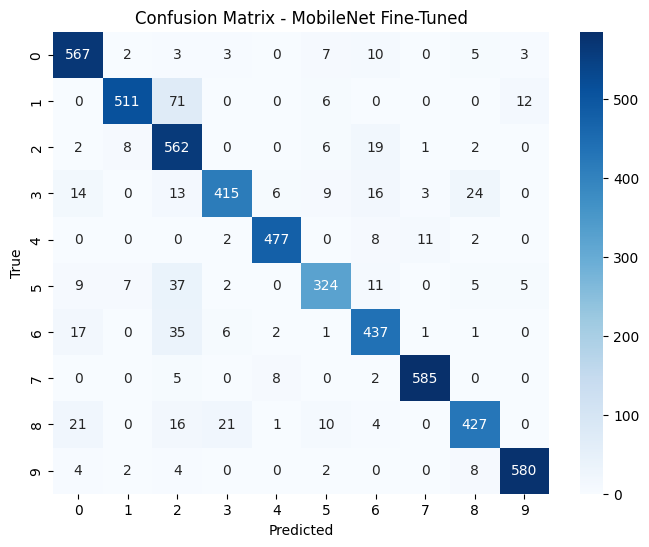

In [9]:
val_generator.reset()
predictions = model_mobilenet.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - MobileNet Fine-Tuned")
plt.show()

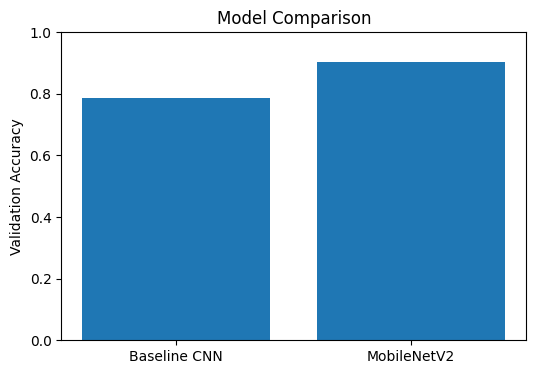

In [10]:
models = ["Baseline CNN", "MobileNetV2"]
accuracies = [
    history_baseline.history['val_accuracy'][-1],
    history_finetune.history['val_accuracy'][-1]
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylim(0,1)
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.show()

In [11]:
_ = model_mobilenet(tf.zeros((1, 224, 224, 3)))

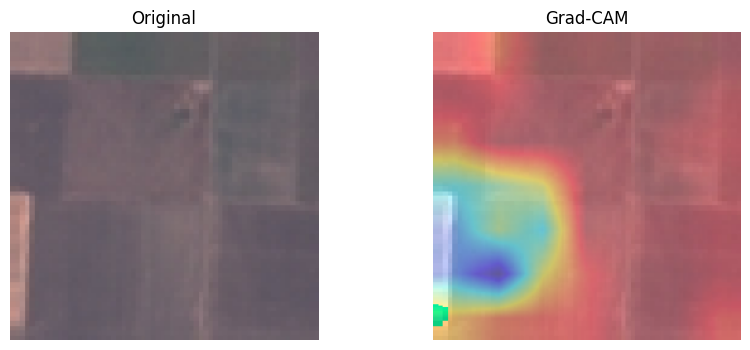

In [13]:
last_conv_layer = base_model.get_layer("out_relu")

# Explicitly build the model before accessing its input attribute
_ = model_mobilenet(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))

# Create a model that returns the output of the last convolutional layer
feature_extractor = tf.keras.models.Model(inputs=base_model.input, outputs=last_conv_layer.output)

# Create a classifier model that takes the output of the last conv layer as input
# and outputs the predictions (the rest of model_mobilenet after base_model)
classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
x = classifier_input
# Iterate through the layers of model_mobilenet after base_model
# This assumes model_mobilenet's layers are [base_model, GlobalAveragePooling2D, Dropout, Dense]
for layer in model_mobilenet.layers[1:]:
    x = layer(x)
classifier_model = tf.keras.models.Model(inputs=classifier_input, outputs=x)

img_path = "EuroSAT/AnnualCrop/AnnualCrop_1.jpg"
img = keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.cast(img_array, tf.float32)

with tf.GradientTape() as tape:
    # Compute the activations of the last conv layer and make sure they are watched
    last_conv_layer_output = feature_extractor(img_array)
    tape.watch(last_conv_layer_output)

    # Pass the activations through the classifier to get the final predictions
    predictions = classifier_model(last_conv_layer_output)

    # Get the top predicted class
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, last_conv_layer_output)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

# Process the heatmap as before
last_conv_layer_output = last_conv_layer_output[0]
heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

img_np = np.array(img)
superimposed_img = heatmap * 0.4 + img_np
superimposed_img = np.uint8(superimposed_img)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_np)
plt.axis("off")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

In [14]:
model_mobilenet.save("mobilenet_landcover.h5")

In [15]:
from google.colab import files
files.download("mobilenet_landcover.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>